# 📡 DoNext 5G — NB4_DSO3 : Prédiction Next Best Cell

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → DSO2 ✅ → **NB4_DSO3**

---
### 🎯 Objectif
Prédire la prochaine cellule cible lors d'un handover (classification multi-classes).

### 📊 Label DSO3
```
next_cell = cell_index[t+1]  quand handover[t] == 1
Filtré sur TOP_N=50 cellules les plus fréquentes
Métriques: Top-1 Accuracy, Top-3 Accuracy, F1-macro
```

### ✅ CORRECTIONS APPORTÉES
1. **cluster_id** : Vérification présence dans COLS_X
2. **BiLSTM** : Bug `_t-{k}` → `_T{k}` (format NB2)
3. **Matrices** : Converties en **pourcentage** pour chaque modèle
4. **Noms fichiers** : Identiques à l'original


---
## Section 0 — Setup


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, top_k_accuracy_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#3A3D4D','axes.labelcolor':'#E0E0E0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0',
    'grid.color':'#2A2D3A','grid.linestyle':'--',
    'grid.alpha':0.5,'font.family':'monospace','figure.dpi':130
})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'
RED='#EF5350'; PURPLE='#CE93D8'

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
FE_DATA_DIR   = os.path.join(DATASET_ROOT, 'FE_data')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO3')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

TOP_N_CELLS = 50
TOP_K_EVAL  = 3
print(f'✅ Setup OK | TOP_N={TOP_N_CELLS} | TOP_K={TOP_K_EVAL}')

✅ Setup OK | TOP_N=50 | TOP_K=3


---
## Section 1 — Construction du Label Next Cell


In [2]:
# ── Label: next_cell = cellule cible du handover ─────────────
CONFIGS = {'static':'session_id','mobile':'device','hbahn':'device'}

df_ho = pd.read_parquet(
    os.path.join(FE_DATA_DIR, 'df_ho.parquet'),
    columns=['session_id','device','source_folder','cell_index','handover']
)
df_ho['next_cell'] = np.nan

for env, cle in CONFIGS.items():
    if cle not in df_ho.columns: continue
    mask_env = df_ho['source_folder'] == env
    for name, grp in df_ho[mask_env].groupby(cle):
        df_ho.loc[grp.index, 'next_cell'] = grp['cell_index'].shift(-1)

df_ho_only = df_ho[
    df_ho['handover'] == 1
].dropna(subset=['next_cell'])
print(f'Handovers avec next_cell : {len(df_ho_only):,}')

cell_counts = df_ho_only['next_cell'].value_counts()
top_cells   = cell_counts.head(TOP_N_CELLS).index.tolist()
coverage    = cell_counts.head(TOP_N_CELLS).sum() / cell_counts.sum() * 100
print(f'Top-{TOP_N_CELLS} couvre {coverage:.1f}% des HO')

df_filtered = df_ho_only[
    df_ho_only['next_cell'].isin(top_cells)
].copy()

le = LabelEncoder()
df_filtered['next_cell_enc'] = le.fit_transform(
    df_filtered['next_cell'].astype(str)
)
N_CLASSES = len(le.classes_)

with open(os.path.join(MODEL_OUT_DIR,'label_encoder_cells.pkl'),'wb') as f:
    pickle.dump(le, f)
print(f'{N_CLASSES} classes | {len(df_filtered):,} handovers retenus')

Handovers avec next_cell : 223,141
Top-50 couvre 58.8% des HO
50 classes | 131,167 handovers retenus


In [3]:
# ── Chargement features + split stratifié ────────────────────
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split

with open(os.path.join(PT_OUT_DIR,'config.json')) as f:
    config = json.load(f)

# ✅ CORRECTION: vérifier cluster_id dans COLS_X
pf = pq.ParquetFile(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet')
)
schema_cols = pf.schema_arrow.names
COLS_X = [c for c in config['cols_X'] if c in schema_cols]

print(f'Vérifications:')
print(f'  cluster_id dans COLS_X: {"cluster_id" in COLS_X}')
print(f'  Total features: {len(COLS_X)}')
assert 'cluster_id' in COLS_X, \
    '❌ cluster_id absent! Relancer NB3 corrigé.'

df_pre = pd.read_parquet(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet'),
    columns=COLS_X
)
common_idx  = df_filtered.index[df_filtered.index.isin(df_pre.index)]
df_filtered = df_filtered.loc[common_idx]
X_all = df_pre.loc[common_idx, COLS_X].values.astype(np.float32)
y_all = df_filtered['next_cell_enc'].values
del df_pre; gc.collect()

# Split stratifié
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all,
    test_size=0.15, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15/0.85, random_state=42, stratify=y_temp
)
del X_temp, y_temp; gc.collect()

# Réencoder proprement sur y_train
le2 = LabelEncoder()
y_train = le2.fit_transform(y_train)

def align_labels(y_raw, le):
    mapping = {c: i for i, c in enumerate(le.classes_)}
    return np.array([mapping.get(c, -1) for c in y_raw])

y_val  = align_labels(y_val,  le2)
y_test = align_labels(y_test, le2)

mask_val  = y_val  != -1
mask_test = y_test != -1
X_val,  y_val  = X_val[mask_val],   y_val[mask_val]
X_test, y_test = X_test[mask_test], y_test[mask_test]

N_CLASSES = len(le2.classes_)
with open(os.path.join(MODEL_OUT_DIR,'label_encoder_cells.pkl'),'wb') as f:
    pickle.dump(le2, f)

print(f'✅ Split stratifié | {N_CLASSES} classes')
print(f'   train={len(X_train):,} | val={len(X_val):,} | test={len(X_test):,}')
print(f'   X_train {X_train.shape}')

# Préparer labels top-15 pour matrices
top15_cls   = pd.Series(y_test).value_counts().head(15).index.tolist()
mask_top    = np.isin(y_test, top15_cls)
cell_labels = [str(le2.classes_[i])[:8] for i in top15_cls]

Vérifications:
  cluster_id dans COLS_X: True
  Total features: 101
✅ Split stratifié | 50 classes
   train=91,816 | val=19,675 | test=19,676
   X_train (91816, 101)


---
## Section 2 — M1 : XGBoost


In [4]:
print('='*60+'\n  M1 — XGBoost DSO3\n'+'='*60)

xgb_d3 = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=N_CLASSES,
    eval_metric='mlogloss', early_stopping_rounds=20,
    tree_method='hist', random_state=42, n_jobs=-1,
    use_label_encoder=False
)
xgb_d3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], verbose=30
)
y_pred_xgb  = xgb_d3.predict(X_test)
y_proba_xgb = xgb_d3.predict_proba(X_test)

acc_xgb  = accuracy_score(y_test, y_pred_xgb)
topk_xgb = top_k_accuracy_score(
    y_test, y_proba_xgb, k=TOP_K_EVAL,
    labels=np.arange(N_CLASSES)
)
f1_xgb = f1_score(
    y_test, y_pred_xgb, average='macro', zero_division=0
)
metrics_xgb = {
    'model':    'XGBoost',
    'accuracy': round(acc_xgb, 4),
    f'top{TOP_K_EVAL}_acc': round(topk_xgb, 4),
    'f1_macro': round(f1_xgb, 4)
}
print(f'  Acc={acc_xgb:.4f} | Top-{TOP_K_EVAL}={topk_xgb:.4f} | F1={f1_xgb:.4f}')

with open(os.path.join(MODEL_OUT_DIR,'xgb_dso3.pkl'),'wb') as f:
    pickle.dump(xgb_d3, f)
print('✅ xgb_dso3.pkl sauvegardé')

  M1 — XGBoost DSO3
[0]	validation_0-mlogloss:2.23960
[30]	validation_0-mlogloss:0.69778
[60]	validation_0-mlogloss:0.58383
[90]	validation_0-mlogloss:0.56128
[120]	validation_0-mlogloss:0.55496
[150]	validation_0-mlogloss:0.55226
[180]	validation_0-mlogloss:0.55182
[196]	validation_0-mlogloss:0.55230
  Acc=0.7818 | Top-3=0.9709 | F1=0.8475
✅ xgb_dso3.pkl sauvegardé


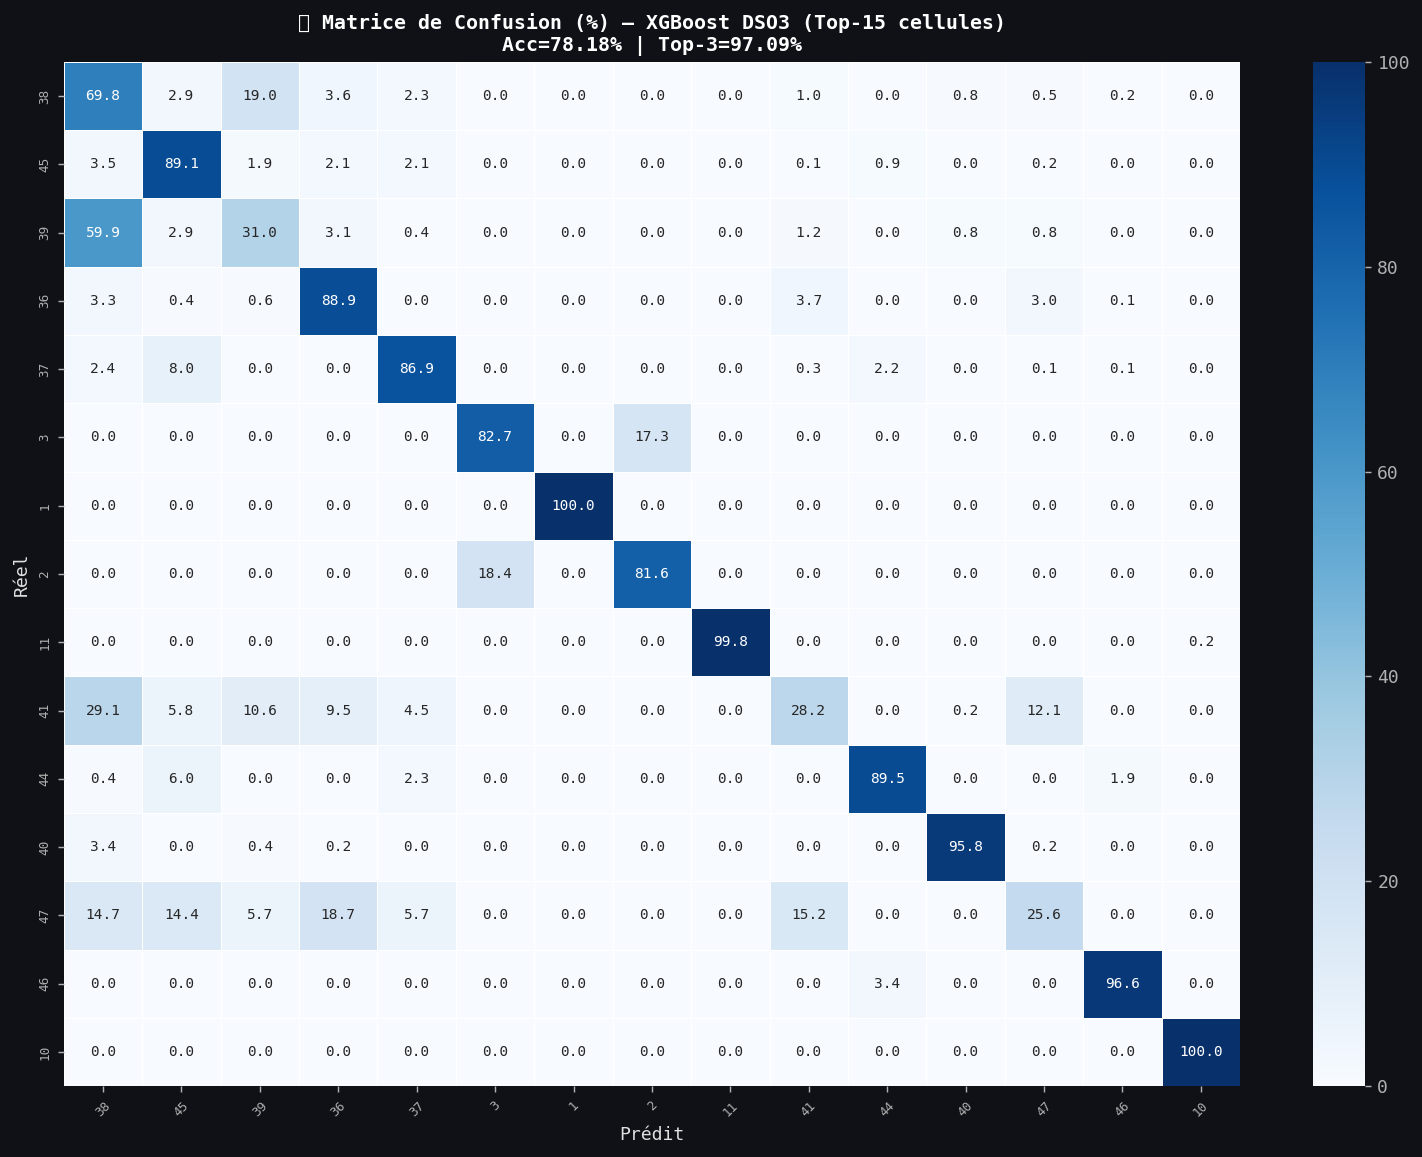

  Précision moyenne par cellule (diagonale): 77.7%


In [5]:
# ── Matrice de Confusion % — XGBoost (Top-15 cellules) ───────
# ✅ CORRECTION: normalisée en % (pas valeurs absolues)
cm_xgb     = confusion_matrix(
    y_test[mask_top], y_pred_xgb[mask_top], labels=top15_cls
)
# Normalisation par ligne → pourcentage réel
cm_xgb_pct = cm_xgb.astype('float') / (
    cm_xgb.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_xgb_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax,
    annot_kws={'size': 8}, vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=10)
ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title(
    f'📊 Matrice de Confusion (%) — XGBoost DSO3 '
    f'(Top-15 cellules)\n'
    f'Acc={acc_xgb*100:.2f}% | Top-{TOP_K_EVAL}={topk_xgb*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_xgb_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()

# Diagonale = bonnes prédictions
diag_mean = np.diag(cm_xgb_pct).mean()
print(f'  Précision moyenne par cellule (diagonale): {diag_mean:.1f}%')

---
## Section 3 — M2 : LightGBM


In [6]:
print('='*60+'\n  M2 — LightGBM DSO3\n'+'='*60)

lgbm_d3 = LGBMClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.1,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    objective='multiclass', num_class=N_CLASSES,
    metric='multi_logloss', class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_d3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(30)
    ]
)
y_pred_lgbm  = lgbm_d3.predict(X_test)
y_proba_lgbm = lgbm_d3.predict_proba(X_test)

acc_lgbm  = accuracy_score(y_test, y_pred_lgbm)
topk_lgbm = top_k_accuracy_score(
    y_test, y_proba_lgbm, k=TOP_K_EVAL,
    labels=np.arange(N_CLASSES)
)
f1_lgbm = f1_score(
    y_test, y_pred_lgbm, average='macro', zero_division=0
)
metrics_lgbm = {
    'model':    'LightGBM',
    'accuracy': round(acc_lgbm, 4),
    f'top{TOP_K_EVAL}_acc': round(topk_lgbm, 4),
    'f1_macro': round(f1_lgbm, 4)
}
print(f'  Acc={acc_lgbm:.4f} | Top-{TOP_K_EVAL}={topk_lgbm:.4f} | F1={f1_lgbm:.4f}')

with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso3.pkl'),'wb') as f:
    pickle.dump(lgbm_d3, f)
print('✅ lgbm_dso3.pkl sauvegardé')

  M2 — LightGBM DSO3
[30]	valid_0's multi_logloss: 0.673334
[60]	valid_0's multi_logloss: 0.636942
  Acc=0.7578 | Top-3=0.9608 | F1=0.8408
✅ lgbm_dso3.pkl sauvegardé


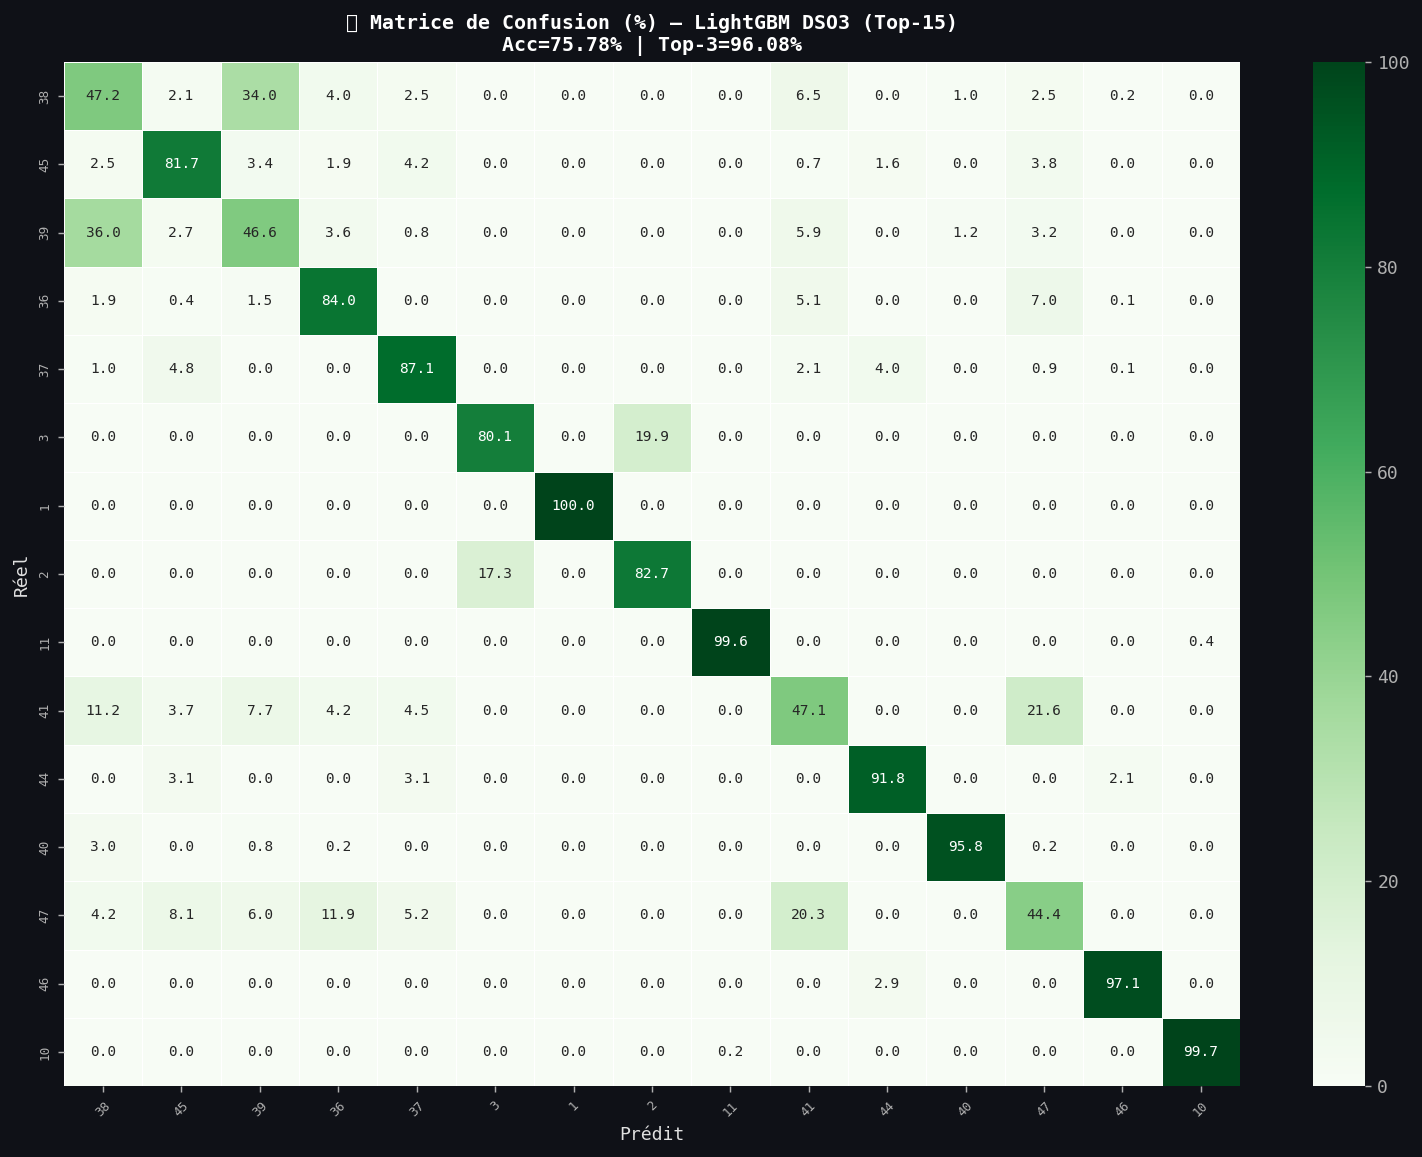

  Précision moyenne par cellule: 79.0%


In [7]:
# ── Matrice de Confusion % — LightGBM (Top-15) ───────────────
cm_lgbm = confusion_matrix(
    y_test[mask_top], y_pred_lgbm[mask_top], labels=top15_cls
)
cm_lgbm_pct = cm_lgbm.astype('float') / (
    cm_lgbm.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_lgbm_pct, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax,
    annot_kws={'size': 8}, vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=10)
ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title(
    f'📊 Matrice de Confusion (%) — LightGBM DSO3 (Top-15)\n'
    f'Acc={acc_lgbm*100:.2f}% | Top-{TOP_K_EVAL}={topk_lgbm*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
diag_mean = np.diag(cm_lgbm_pct).mean()
print(f'  Précision moyenne par cellule: {diag_mean:.1f}%')

---
## Section 4 — M3 : Random Forest


In [8]:
print('='*60+'\n  M3 — Random Forest DSO3\n'+'='*60)

rf_d3 = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_leaf=10, max_features='sqrt',
    class_weight='balanced_subsample',
    max_samples=0.3, random_state=42,
    n_jobs=-1, verbose=1
)
rf_d3.fit(X_train, y_train)
y_pred_rf  = rf_d3.predict(X_test)
y_proba_rf = rf_d3.predict_proba(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
topk_rf = top_k_accuracy_score(
    y_test, y_proba_rf, k=TOP_K_EVAL,
    labels=np.arange(N_CLASSES)
)
f1_rf = f1_score(
    y_test, y_pred_rf, average='macro', zero_division=0
)
metrics_rf = {
    'model':    'Random Forest',
    'accuracy': round(acc_rf, 4),
    f'top{TOP_K_EVAL}_acc': round(topk_rf, 4),
    'f1_macro': round(f1_rf, 4)
}
print(f'  Acc={acc_rf:.4f} | Top-{TOP_K_EVAL}={topk_rf:.4f} | F1={f1_rf:.4f}')

with open(os.path.join(MODEL_OUT_DIR,'rf_dso3.pkl'),'wb') as f:
    pickle.dump(rf_d3, f)
print('✅ rf_dso3.pkl sauvegardé')

  M3 — Random Forest DSO3


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   12.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.8s finished


  Acc=0.7304 | Top-3=0.9552 | F1=0.7879
✅ rf_dso3.pkl sauvegardé


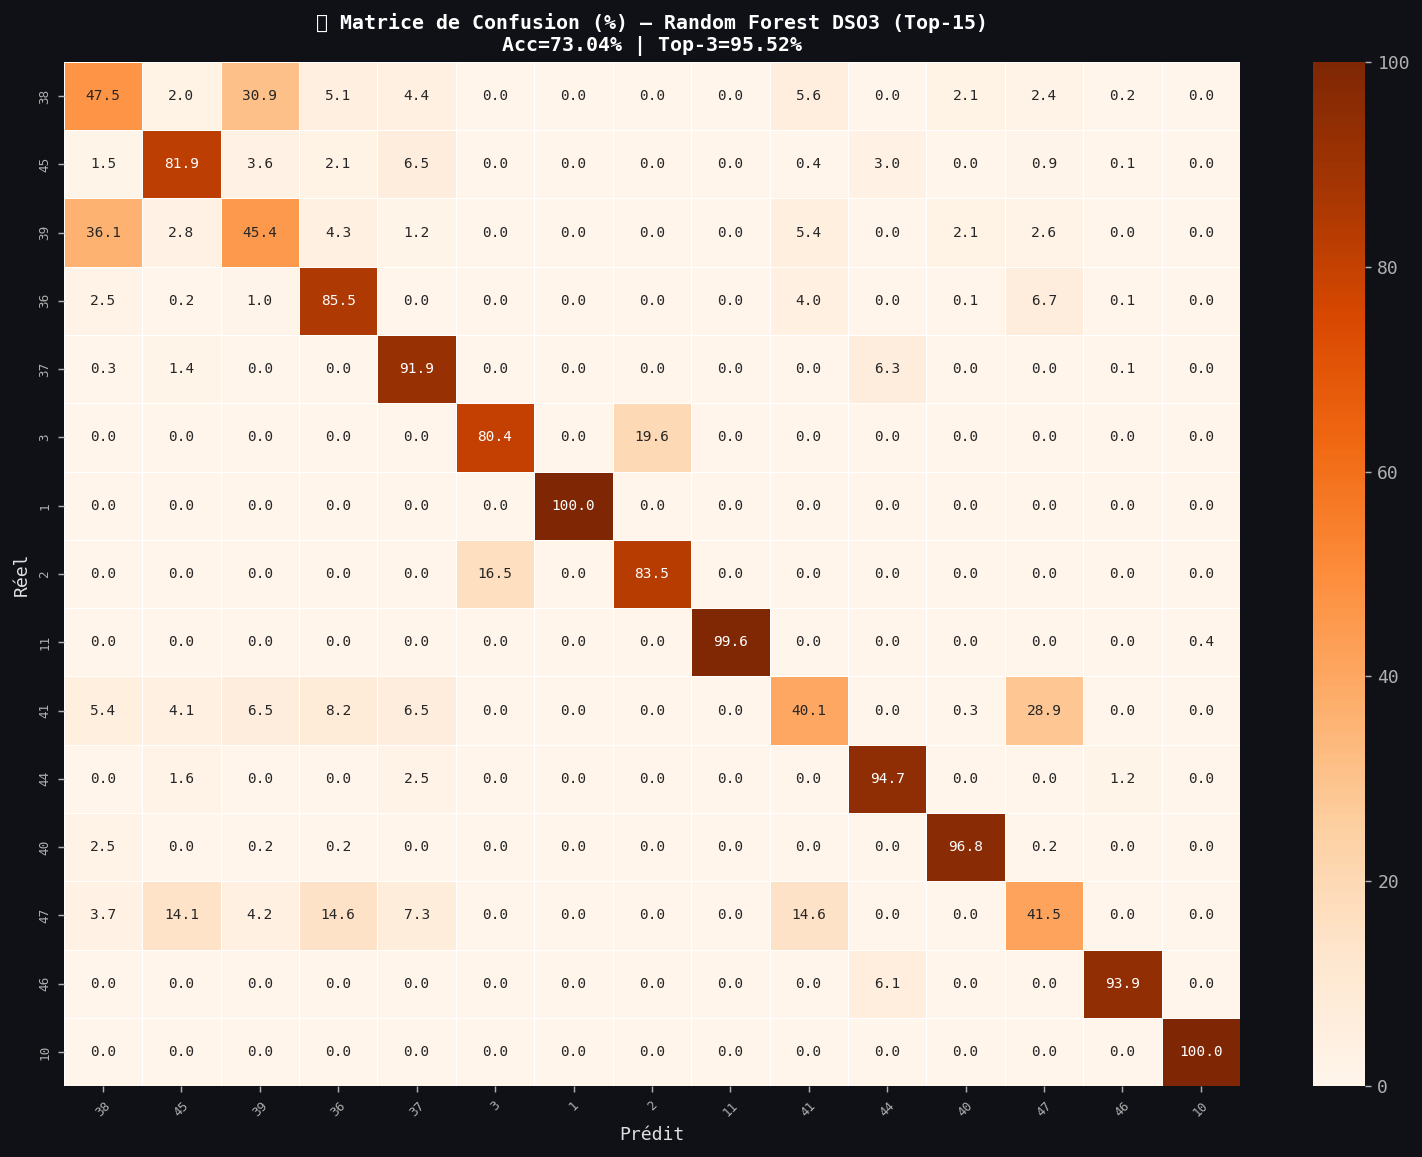

  Précision moyenne par cellule: 78.8%


In [9]:
# ── Matrice de Confusion % — Random Forest (Top-15) ──────────
cm_rf = confusion_matrix(
    y_test[mask_top], y_pred_rf[mask_top], labels=top15_cls
)
cm_rf_pct = cm_rf.astype('float') / (
    cm_rf.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_rf_pct, annot=True, fmt='.1f', cmap='Oranges',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax,
    annot_kws={'size': 8}, vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=10)
ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title(
    f'📊 Matrice de Confusion (%) — Random Forest DSO3 (Top-15)\n'
    f'Acc={acc_rf*100:.2f}% | Top-{TOP_K_EVAL}={topk_rf*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_rf_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
diag_mean = np.diag(cm_rf_pct).mean()
print(f'  Précision moyenne par cellule: {diag_mean:.1f}%')

---
## Section 5 — M4 : LSTM Softmax


In [10]:
print('='*60+'\n  M4 — LSTM Softmax DSO3\n'+'='*60)

# ✅ CORRECTION BUG: '_t-{k}' → '_T{k}'
WINDOW_COLS = [
    c for c in COLS_X
    if any(f'_T{k}' in c for k in range(1, 6))  # ← CORRIGÉ
]
print(f'  WINDOW_COLS: {len(WINDOW_COLS)} colonnes')

T = 5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx   = [list(COLS_X).index(c) for c in WINDOW_COLS]
    F       = len(w_idx) // T
    X_tr_3d = X_train[:, w_idx].reshape(-1, T, F)
    X_va_3d = X_val[:,   w_idx].reshape(-1, T, F)
    X_te_3d = X_test[:,  w_idx].reshape(-1, T, F)
else:
    print('  ⚠️ WINDOW_COLS vide → fallback T=1')
    F       = X_train.shape[1]; T = 1
    X_tr_3d = X_train.reshape(-1, 1, F)
    X_va_3d = X_val.reshape(-1,   1, F)
    X_te_3d = X_test.reshape(-1,  1, F)

print(f'  Shape 3D: {X_tr_3d.shape}')

y_tr_cat = to_categorical(y_train, N_CLASSES)
y_va_cat = to_categorical(y_val,   N_CLASSES)

cw_arr  = compute_class_weight(
    'balanced', classes=np.arange(N_CLASSES), y=y_train
)
cw_dict = {i: cw_arr[i] for i in range(N_CLASSES)}

tf.random.set_seed(42)
inp = Input(shape=(T, F))
x   = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inp)
x   = BatchNormalization()(x)
x   = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(x)
x   = BatchNormalization()(x)
x   = Dense(128, activation='relu')(x)
x   = Dropout(0.3)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(N_CLASSES, activation='softmax')(x)

lstm_d3 = Model(inputs=inp, outputs=out, name='LSTM_DSO3')
lstm_d3.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=TOP_K_EVAL)]
)

history_d3 = lstm_d3.fit(
    X_tr_3d, y_tr_cat,
    validation_data=(X_va_3d, y_va_cat),
    class_weight=cw_dict,
    epochs=30, batch_size=1024, verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6
        ),
        ModelCheckpoint(
            os.path.join(MODEL_OUT_DIR,'lstm_dso3_best.h5'),
            monitor='val_accuracy',
            save_best_only=True, mode='max'
        )
    ]
)

y_proba_lstm = lstm_d3.predict(
    X_te_3d, batch_size=2048, verbose=0
)
y_pred_lstm = y_proba_lstm.argmax(axis=1)

acc_lstm  = accuracy_score(y_test, y_pred_lstm)
topk_lstm = top_k_accuracy_score(
    y_test, y_proba_lstm, k=TOP_K_EVAL,
    labels=np.arange(N_CLASSES)
)
f1_lstm = f1_score(
    y_test, y_pred_lstm, average='macro', zero_division=0
)
metrics_lstm = {
    'model':    'BiLSTM',
    'accuracy': round(acc_lstm, 4),
    f'top{TOP_K_EVAL}_acc': round(topk_lstm, 4),
    'f1_macro': round(f1_lstm, 4)
}
print(f'  Acc={acc_lstm:.4f} | Top-{TOP_K_EVAL}={topk_lstm:.4f} | F1={f1_lstm:.4f}')

lstm_d3.save(os.path.join(MODEL_OUT_DIR,'lstm_dso3.h5'))
print('✅ lstm_dso3.h5 sauvegardé')

  M4 — LSTM Softmax DSO3
  WINDOW_COLS: 45 colonnes
  Shape 3D: (91816, 5, 9)
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.0312 - loss: 3.9112 - top_k_categorical_accuracy: 0.0858 

90/90 ━━━━━━━━━━━━━━━━━━━━ 86s 404ms/step - accuracy: 0.0488 - loss: 3.8026 - top_k_categorical_accuracy: 0.1267 - val_accuracy: 0.0213 - val_loss: 3.9041 - val_top_k_categorical_accuracy: 0.0608 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.1155 - loss: 3.2395 - top_k_categorical_accuracy: 0.2799 

90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.1322 - loss: 3.0675 - top_k_categorical_accuracy: 0.3200 - val_accuracy: 0.0499 - val_loss: 3.8007 - val_top_k_categorical_accuracy: 0.1266 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.1829 - loss: 2.6642 - top_k_categorical_accuracy: 0.4208 

90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 332ms/step - accuracy: 0.1889 - loss: 2.6106 - top_k_categorical_accuracy: 0.4329 - val_accuracy: 0.0817 - val_loss: 3.5519 - val_top_k_categorical_accuracy: 0.1916 - learning_rate: 0.0010
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.2122 - loss: 2.4367 - top_k_categorical_accuracy: 0.4818 

90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 323ms/step - accuracy: 0.2166 - loss: 2.4128 - top_k_categorical_accuracy: 0.4873 - val_accuracy: 0.1160 - val_loss: 3.1121 - val_top_k_categorical_accuracy: 0.3164 - learning_rate: 0.0010
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.2403 - loss: 2.3094 - top_k_categorical_accuracy: 0.5210 

...

90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 333ms/step - accuracy: 0.2659 - loss: 2.1758 - top_k_categorical_accuracy: 0.5596 - val_accuracy: 0.2698 - val_loss: 2.1500 - val_top_k_categorical_accuracy: 0.5768 - learning_rate: 0.0010
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.2751 - loss: 2.1373 - top_k_categorical_accuracy: 0.5743 

90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.2746 - loss: 2.1393 - top_k_categorical_accuracy: 0.5726 - val_accuracy: 0.2920 - val_loss: 2.0626 - val_top_k_categorical_accuracy: 0.5924 - learning_rate: 0.0010
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.2845 - loss: 2.1034 - top_k_categorical_accuracy: 0.5883 

90/90 ━━━━━━━━━━━━━━━━━━━━ 28s 311ms/step - accuracy: 0.2826 - loss: 2.1040 - top_k_categorical_accuracy: 0.5861 - val_accuracy: 0.3162 - val_loss: 2.0084 - val_top_k_categorical_accuracy: 0.6276 - learning_rate: 0.0010
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 274ms/step - accuracy: 0.2935 - loss: 2.0733 - top_k_categorical_accuracy: 0.5962 - val_accuracy: 0.3013 - val_loss: 2.0083 - val_top_k_categorical_accuracy: 0.6290 - learning_rate: 0.0010
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3004 - loss: 2.0505 - top_k_categorical_accuracy: 0.6091 

90/90 ━━━━━━━━━━━━━━━━━━━━ 27s 302ms/step - accuracy: 0.2977 - loss: 2.0557 - top_k_categorical_accuracy: 0.6061 - val_accuracy: 0.3279 - val_loss: 1.9273 - val_top_k_categorical_accuracy: 0.6487 - learning_rate: 0.0010
Epoch 12/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 26s 283ms/step - accuracy: 0.3047 - loss: 2.0296 - top_k_categorical_accuracy: 0.6113 - val_accuracy: 0.3235 - val_loss: 1.9391 - val_top_k_categorical_accuracy: 0.6494 - learning_rate: 0.0010
Epoch 13/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 345ms/step - accuracy: 0.3108 - loss: 2.0100 - top_k_categorical_accuracy: 0.6217 - val_accuracy: 0.3233 - val_loss: 1.9509 - val_top_k_categorical_accuracy: 0.6446 - learning_rate: 0.0010
Epoch 14/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 337ms/step - accuracy: 0.3191 - loss: 1.9885 - top_k_categorical_accuracy: 0.6311 - val_accuracy: 0.3210 - val_loss: 1.9440 - val_top_k_categorical_accuracy: 0.6538 - learning_rate: 0.0010
Epoch 15/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 316ms/step - accuracy: 0.3238 - loss: 1.9

  Acc=0.3297 | Top-3=0.6491 | F1=0.3083
✅ lstm_dso3.h5 sauvegardé


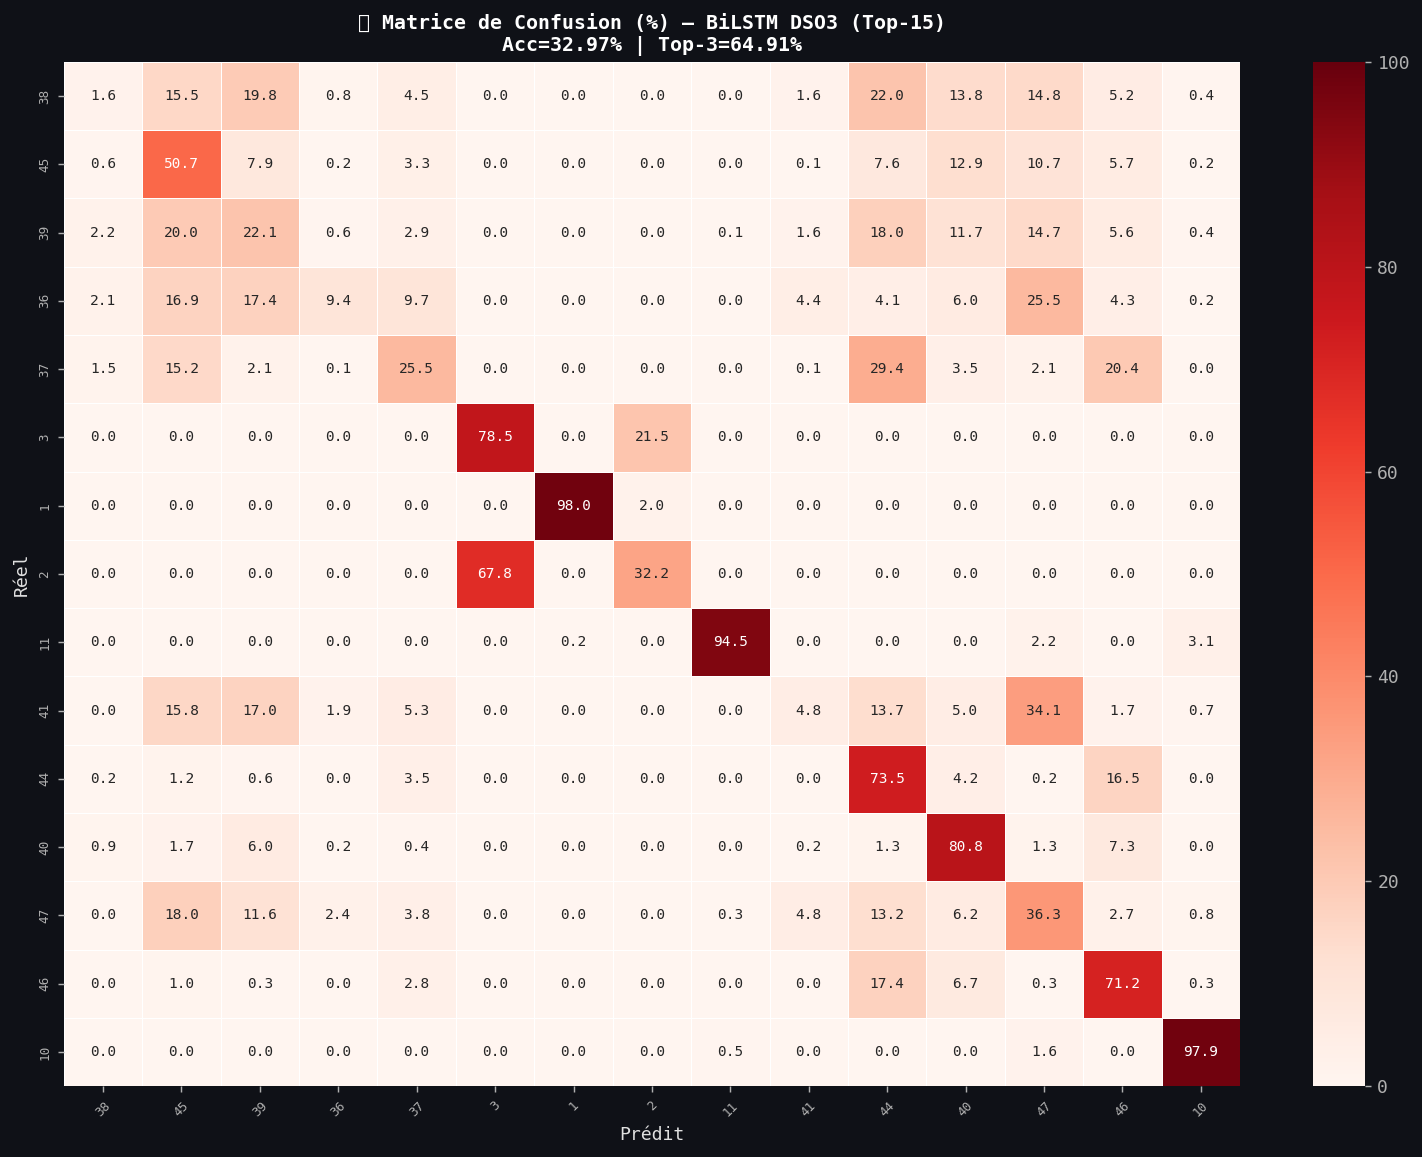

  Précision moyenne par cellule: 51.8%


In [11]:
# ── Matrice de Confusion % — BiLSTM (Top-15) ─────────────────
cm_lstm = confusion_matrix(
    y_test[mask_top], y_pred_lstm[mask_top], labels=top15_cls
)
cm_lstm_pct = cm_lstm.astype('float') / (
    cm_lstm.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_lstm_pct, annot=True, fmt='.1f', cmap='Reds',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax,
    annot_kws={'size': 8}, vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=10)
ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title(
    f'📊 Matrice de Confusion (%) — BiLSTM DSO3 (Top-15)\n'
    f'Acc={acc_lstm*100:.2f}% | Top-{TOP_K_EVAL}={topk_lstm*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lstm_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
diag_mean = np.diag(cm_lstm_pct).mean()
print(f'  Précision moyenne par cellule: {diag_mean:.1f}%')

---
## Section 6 — M5 : TabNet


In [12]:
print('='*60+'\n  M5 — TabNet DSO3\n'+'='*60)

# ── 1. Sampling ───────────────────────────────────────────────
N_TN       = min(100_000, len(X_train))
idx_tn     = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_tn].astype(np.float32)
X_va_tn    = X_val.astype(np.float32)
X_te_tn    = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train: {len(X_tr_tn):,}')

# ── 2. Pretraining ────────────────────────────────────────────
pt_d3 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d3.fit(
    X_train=X_tr_tn,
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ───────────────────────────────────────
tabnet_d3 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# Mini-fit pour initialiser
tabnet_d3.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)
tabnet_d3.load_weights_from_unsupervised(pt_d3)

# ── 4. Entraînement réel ──────────────────────────────────────
tabnet_d3.verbose = 10
tabnet_d3.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['accuracy'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)

y_pred_tn  = tabnet_d3.predict(X_te_tn)
y_proba_tn = tabnet_d3.predict_proba(X_te_tn)

acc_tn  = accuracy_score(y_test, y_pred_tn)
topk_tn = top_k_accuracy_score(
    y_test, y_proba_tn, k=TOP_K_EVAL,
    labels=np.arange(N_CLASSES)
)
f1_tn = f1_score(
    y_test, y_pred_tn, average='macro', zero_division=0
)
metrics_tn = {
    'model':    'TabNet',
    'accuracy': round(acc_tn, 4),
    f'top{TOP_K_EVAL}_acc': round(topk_tn, 4),
    'f1_macro': round(f1_tn, 4)
}
print(f'  Acc={acc_tn:.4f} | Top-{TOP_K_EVAL}={topk_tn:.4f} | F1={f1_tn:.4f}')

tabnet_d3.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_dso3'))
print('✅ tabnet_dso3 sauvegardé')

  M5 — TabNet DSO3
Sample train: 91,816
epoch 0  | loss: 2755.09729| val_0_unsup_loss_numpy: 141.49981689453125|  0:03:35s
epoch 5  | loss: 4.89852 | val_0_unsup_loss_numpy: 2.0413599014282227|  0:12:58s
epoch 10 | loss: 1.36098 | val_0_unsup_loss_numpy: 1.2790900468826294|  0:14:49s
epoch 15 | loss: 1.10093 | val_0_unsup_loss_numpy: 1.0506500005722046|  0:17:56s
epoch 20 | loss: 1.0245  | val_0_unsup_loss_numpy: 0.922950029373169|  0:22:10s
epoch 25 | loss: 0.9737  | val_0_unsup_loss_numpy: 0.8682000041007996|  0:31:16s
Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_unsup_loss_numpy = 0.8167099952697754
epoch 0  | loss: 4.20012 | val_0_accuracy: 0.02313 |  0:00:24s
epoch 10 | loss: 0.94196 | val_0_accuracy: 0.25184 |  0:04:43s
epoch 20 | loss: 0.72968 | val_0_accuracy: 0.58689 |  0:10:00s
Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_accuracy = 0.63802
  Acc=0.6424 | Top-3=0.9162 | F1=0.7261
Successfully sa

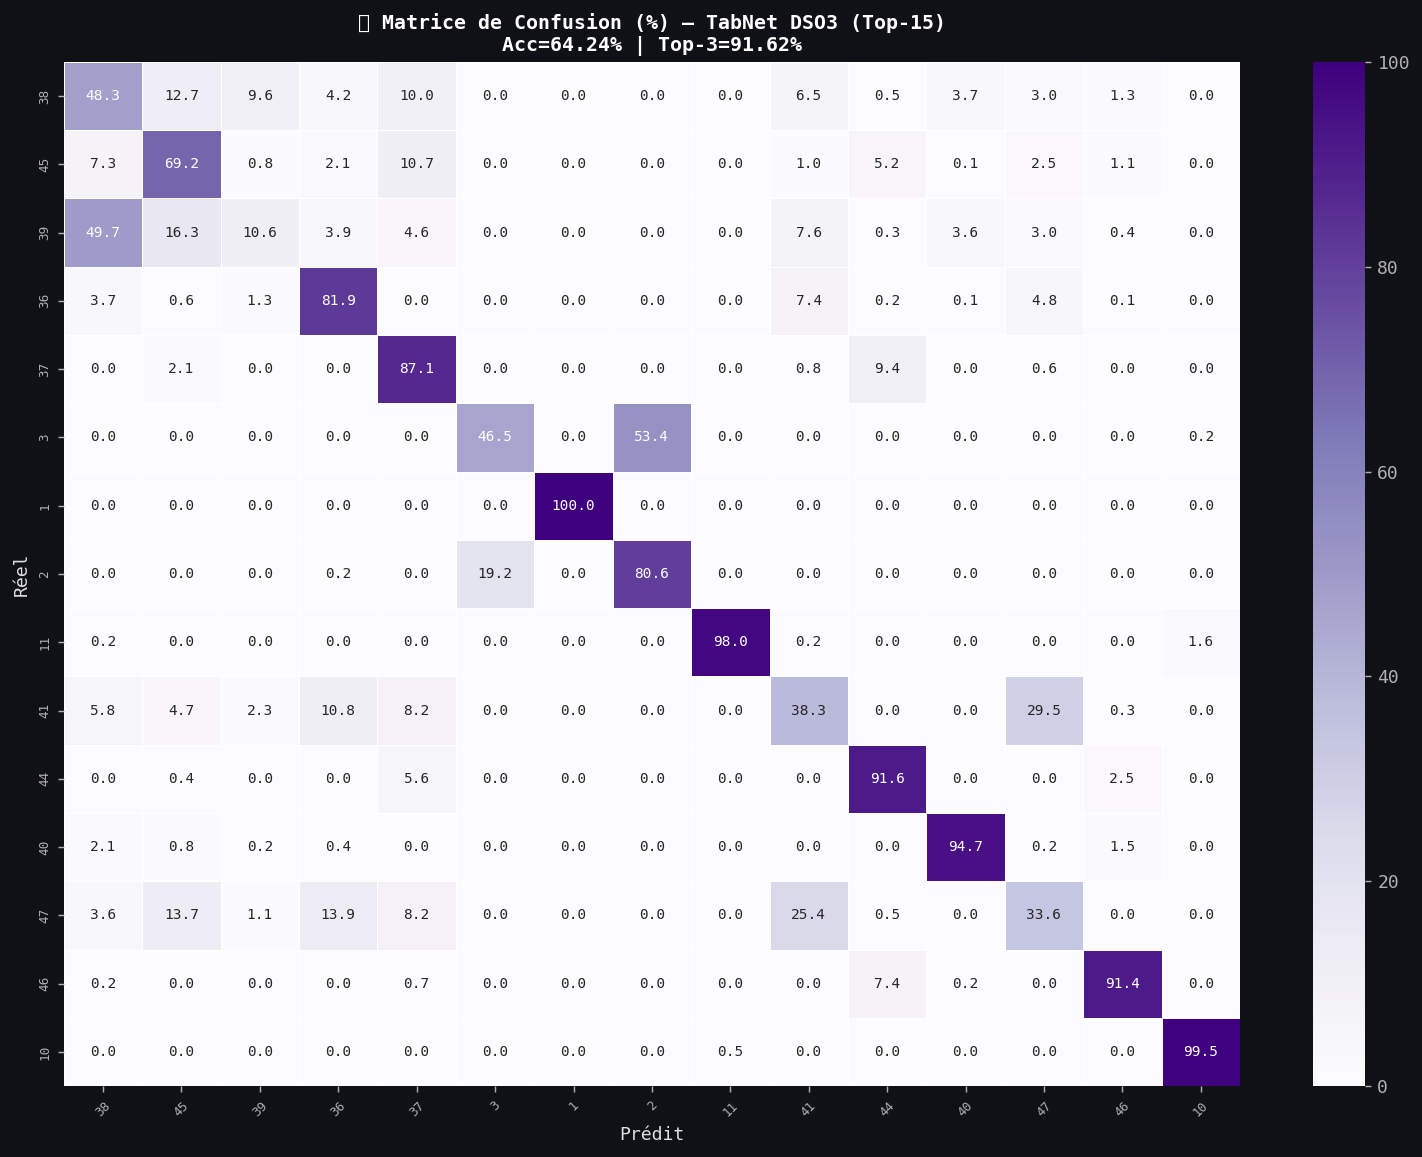

  Précision moyenne par cellule: 71.4%


In [13]:
# ── Matrice de Confusion % — TabNet (Top-15) ─────────────────
cm_tn = confusion_matrix(
    y_test[mask_top], y_pred_tn[mask_top], labels=top15_cls
)
cm_tn_pct = cm_tn.astype('float') / (
    cm_tn.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_tn_pct, annot=True, fmt='.1f', cmap='Purples',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax,
    annot_kws={'size': 8}, vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=10)
ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title(
    f'📊 Matrice de Confusion (%) — TabNet DSO3 (Top-15)\n'
    f'Acc={acc_tn*100:.2f}% | Top-{TOP_K_EVAL}={topk_tn*100:.2f}%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
diag_mean = np.diag(cm_tn_pct).mean()
print(f'  Précision moyenne par cellule: {diag_mean:.1f}%')

---
## Section 7 — Comparaison finale



=== RÉSULTATS DSO3 ===
               accuracy  top3_acc  f1_macro
model                                      
XGBoost          0.7818    0.9709    0.8475
LightGBM         0.7578    0.9608    0.8408
Random Forest    0.7304    0.9552    0.7879
BiLSTM           0.3297    0.6491    0.3083
TabNet           0.6424    0.9162    0.7261

🏆 Meilleur (Accuracy) : XGBoost → 0.7818


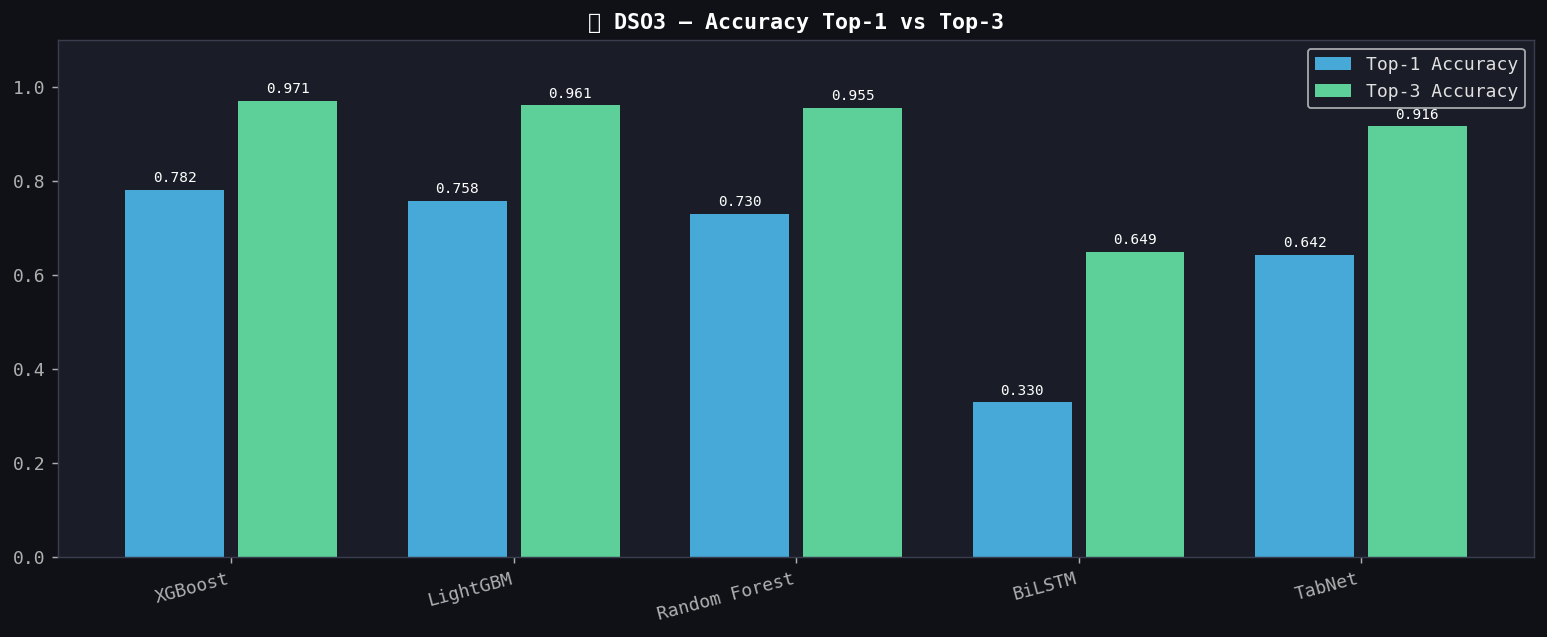


✅ results_dso3.json sauvegardé


In [14]:
all_metrics = [
    metrics_xgb, metrics_lgbm, metrics_rf,
    metrics_lstm, metrics_tn
]
df_results = pd.DataFrame(all_metrics).set_index('model')
print('\n=== RÉSULTATS DSO3 ===')
print(df_results.to_string())

best = df_results['accuracy'].idxmax()
print(f'\n🏆 Meilleur (Accuracy) : {best} → {df_results.loc[best,"accuracy"]:.4f}')

# Graphe comparatif Top-1 vs Top-3
x            = np.arange(5)
models_list  = ['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-0.2, df_results['accuracy'], 0.35,
       label='Top-1 Accuracy', color=BLUE, alpha=0.85)
ax.bar(x+0.2, df_results[f'top{TOP_K_EVAL}_acc'], 0.35,
       label=f'Top-{TOP_K_EVAL} Accuracy', color=GREEN, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_title(
    f'📡 DSO3 — Accuracy Top-1 vs Top-{TOP_K_EVAL}',
    fontweight='bold'
)
ax.legend()
ax.set_ylim(0, 1.1)

# Annoter les valeurs
for i, (acc, topk) in enumerate(zip(
    df_results['accuracy'], df_results[f'top{TOP_K_EVAL}_acc']
)):
    ax.text(i-0.2, acc+0.01, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=8, color='white')
    ax.text(i+0.2, topk+0.01, f'{topk:.3f}',
            ha='center', va='bottom', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'dashboard_dso3.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()

# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'results_dso3.json'),'w') as f:
    json.dump(all_metrics, f, indent=2)
print('\n✅ results_dso3.json sauvegardé')

---
## Bilan NB4 DSO3 — Corrigé

### 📊 Label DSO3
```
next_cell = cell_index[t+1] lors d'un handover
Top-50 cellules les plus fréquentes
Classification multi-classes (50 classes)
```

### ✅ Corrections
| Correction | Avant | Après |
|------------|-------|-------|
| Matrices CM | Valeurs absolues | ✅ En % normalisées par ligne |
| BiLSTM cols | `_t-{k}` (bug) | ✅ `_T{k}` (format NB2) |
| cluster_id | Non vérifié | ✅ Assert présent |
| Titre CM | Sans métriques | ✅ Acc + Top-K dans le titre |
| Diagonale | Non affiché | ✅ Précision moyenne par cellule |

### 💾 Fichiers produits
```
MODEL_output/DSO3/
  xgb_dso3.pkl
  lgbm_dso3.pkl
  rf_dso3.pkl
  lstm_dso3.h5 + lstm_dso3_best.h5
  tabnet_dso3.zip
  label_encoder_cells.pkl
  results_dso3.json
  dashboard_dso3.png
  cm_xgb_dso3.png  cm_lgbm_dso3.png
  cm_rf_dso3.png   cm_lstm_dso3.png
  cm_tabnet_dso3.png
```
